# New Zealand Household Income & Housing Cost Analysis

**Author:** Naysa Maria Manu  
**Date:** July 2026

## Project Overview

This project explores official household income and housing cost data from Stats NZ. The aim is to understand trends in household income and housing affordability using data cleaning, exploratory data analysis (EDA), and visualisation in Python.

---

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [7]:
# Load the dataset

df = pd.read_csv("Table-4.csv")

# Display the first five rows
df.head()

,RegCode,MsCode,IncCode,Estimate,RSE,LowerCIB,UpperCIB
0,R001,M001,I001,108908.0,6.5,101857.0,115959.0
1,R001,M002,I001,83361.0,9.8,75208.0,91514.0
2,R001,M003,I001,4.8,8.9,-4.0,13.7
3,R001,M004,I001,3.9,15.4,-11.5,19.3
4,R002,M001,I001,160687.0,2.3,157022.0,164352.0


In [10]:
print("Shape:", df.shape)
print()

print("Columns:")
print(df.columns)
print()

print("Missing values:")
print(df.isnull().sum())
print()

print("Unique regions:", df["RegCode"].unique())
print()

print("Unique measures:", df["MsCode"].unique())
print()

print("Unique income codes:", df["IncCode"].unique())

Shape: (208, 7)

Columns:
Index(['RegCode', 'MsCode', 'IncCode', 'Estimate', 'RSE', 'LowerCIB',
       'UpperCIB'],
      dtype='object')

Missing values:
RegCode     0
MsCode      0
IncCode     0
Estimate    0
RSE         0
LowerCIB    0
UpperCIB    0
dtype: int64

Unique regions: ['R001' 'R002' 'R003' 'R004' 'R005' 'R006' 'R007' 'R008' 'R009' 'R010'
 'R011' 'R012' 'R013']

Unique measures: ['M001' 'M002' 'M003' 'M004']

Unique income codes: ['I001' 'I002' 'I003' 'I004']


In [11]:
# Count how many records belong to each code

print("Regions")
print(df["RegCode"].value_counts().sort_index())

print("\nMeasures")
print(df["MsCode"].value_counts().sort_index())

print("\nIncome codes")
print(df["IncCode"].value_counts().sort_index())

Regions
RegCode
R001    16
R002    16
R003    16
R004    16
R005    16
R006    16
R007    16
R008    16
R009    16
R010    16
R011    16
R012    16
R013    16
Name: count, dtype: int64

Measures
MsCode
M001    52
M002    52
M003    52
M004    52
Name: count, dtype: int64

Income codes
IncCode
I001    52
I002    52
I003    52
I004    52
Name: count, dtype: int64


In [12]:
# Display all records for the first region

df[df["RegCode"] == "R001"]

,RegCode,MsCode,IncCode,Estimate,RSE,LowerCIB,UpperCIB
0,R001,M001,I001,108908.0,6.5,101857.0,115959.0
1,R001,M002,I001,83361.0,9.8,75208.0,91514.0
2,R001,M003,I001,4.8,8.9,-4.0,13.7
3,R001,M004,I001,3.9,15.4,-11.5,19.3
52,R001,M001,I002,87571.0,5.6,82657.0,92484.0
53,R001,M002,I002,73274.0,8.1,67331.0,79217.0
54,R001,M003,I002,4.3,7.6,-3.2,11.9
55,R001,M004,I002,5.7,12.6,-7.0,18.3
104,R001,M001,I003,52632.0,5.7,49611.0,55653.0
105,R001,M002,I003,45600.0,7.6,42141.0,49058.0


In [13]:
# Replace income and measure codes with readable labels

measure_map = {
    "M001": "Average Income",
    "M002": "Median Income",
    "M003": "Average % Change",
    "M004": "Median % Change"
}

income_map = {
    "I001": "Gross Income",
    "I002": "Disposable Income",
    "I003": "Equivalised Disposable Income",
    "I004": "Equivalised Disposable Income (After Housing Costs)"
}

df["Measure"] = df["MsCode"].map(measure_map)
df["Income Type"] = df["IncCode"].map(income_map)

df.head()

,RegCode,MsCode,IncCode,Estimate,RSE,LowerCIB,UpperCIB,Measure,Income Type
0,R001,M001,I001,108908.0,6.5,101857.0,115959.0,Average Income,Gross Income
1,R001,M002,I001,83361.0,9.8,75208.0,91514.0,Median Income,Gross Income
2,R001,M003,I001,4.8,8.9,-4.0,13.7,Average % Change,Gross Income
3,R001,M004,I001,3.9,15.4,-11.5,19.3,Median % Change,Gross Income
4,R002,M001,I001,160687.0,2.3,157022.0,164352.0,Average Income,Gross Income


In [14]:
# Display the region codes in order

print(sorted(df["RegCode"].unique()))


['R001', 'R002', 'R003', 'R004', 'R005', 'R006', 'R007', 'R008', 'R009', 'R010', 'R011', 'R012', 'R013']


In [15]:
# Replace region codes with region names

region_map = {
    "R001": "Northland",
    "R002": "Auckland",
    "R003": "Waikato",
    "R004": "Bay of Plenty",
    "R005": "Gisborne / Hawke's Bay",
    "R006": "Taranaki",
    "R007": "Manawatu-Whanganui",
    "R008": "Wellington",
    "R009": "West Coast / Tasman / Nelson / Marlborough",
    "R010": "Canterbury",
    "R011": "Otago",
    "R012": "Southland",
    "R013": "New Zealand"
}

df["Region"] = df["RegCode"].map(region_map)

df[["Region", "Measure", "Income Type", "Estimate"]].head()

,Region,Measure,Income Type,Estimate
0,Northland,Average Income,Gross Income,108908.0
1,Northland,Median Income,Gross Income,83361.0
2,Northland,Average % Change,Gross Income,4.8
3,Northland,Median % Change,Gross Income,3.9
4,Auckland,Average Income,Gross Income,160687.0


## Average Gross Household Income by Region

This chart compares the average annual gross household income across New Zealand regions. It highlights regional differences in household earnings using official Stats NZ data.

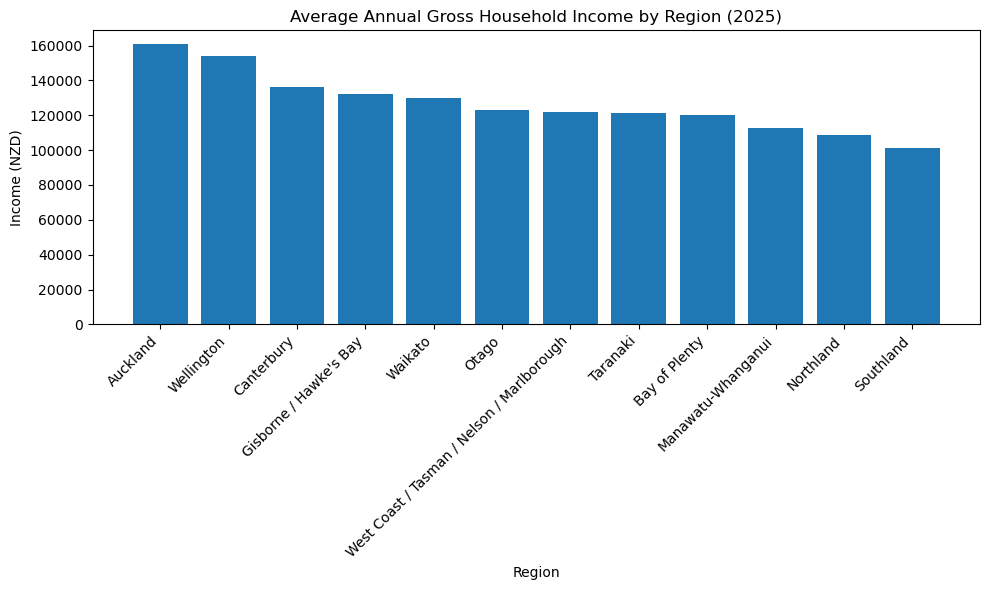

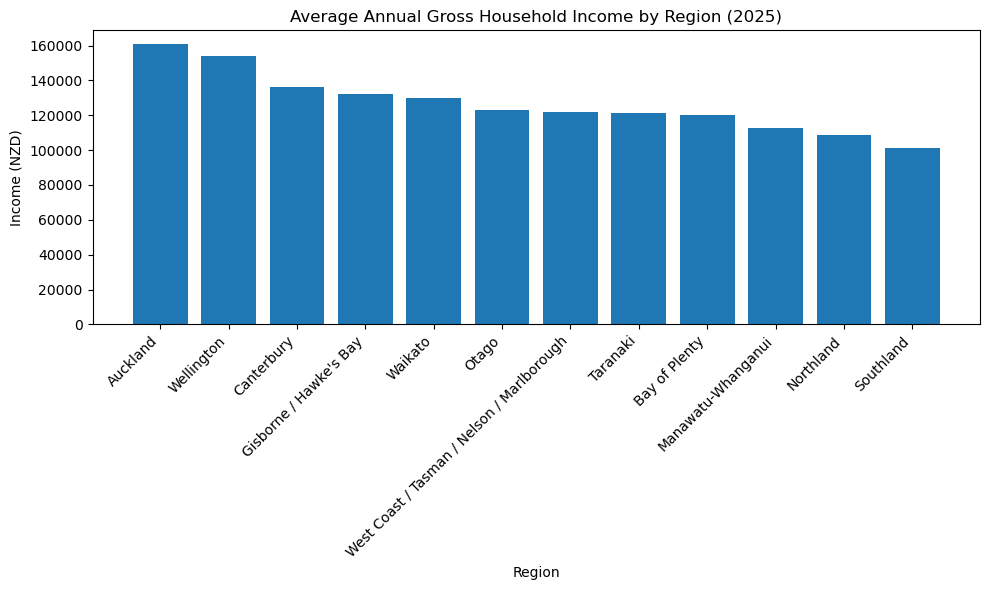

In [23]:
# Filter the data for average gross household income

avg_gross = df[
    (df["Measure"] == "Average Income") &
    (df["Income Type"] == "Gross Income") &
    (df["Region"] != "New Zealand")
]

# Sort regions by income
avg_gross = avg_gross.sort_values("Estimate", ascending=False)

# Create the chart
plt.figure(figsize=(10,6))

plt.bar(avg_gross["Region"], avg_gross["Estimate"])

plt.title("Average Annual Gross Household Income by Region (2025)")
plt.xlabel("Region")
plt.ylabel("Income (NZD)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("average_gross_income_by_region.png", dpi=300, bbox_inches="tight")

plt.show()

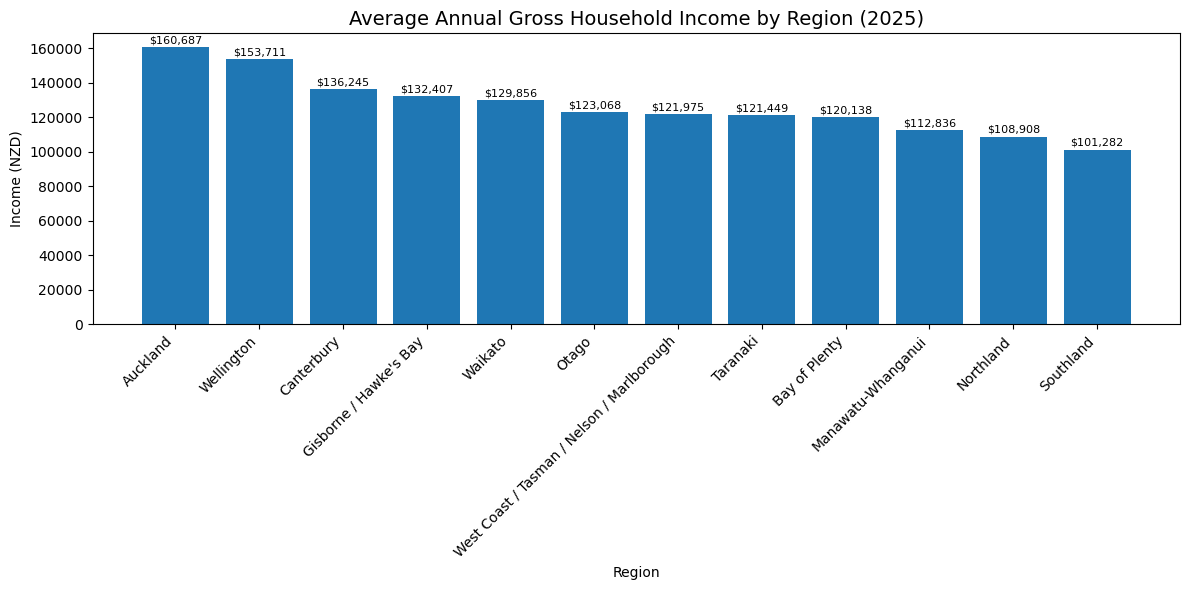

In [17]:
# Filter the data for average gross household income

avg_gross = df[
    (df["Measure"] == "Average Income") &
    (df["Income Type"] == "Gross Income") &
    (df["Region"] != "New Zealand")
].sort_values("Estimate", ascending=False)

plt.figure(figsize=(12,6))

bars = plt.bar(avg_gross["Region"], avg_gross["Estimate"])

plt.title("Average Annual Gross Household Income by Region (2025)", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Income (NZD)")
plt.xticks(rotation=45, ha="right")

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1000,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### Key Insights

- Auckland recorded the highest average annual gross household income among the regions analysed.
- Wellington ranked second, followed by Canterbury.
- Southland recorded the lowest average annual gross household income in the dataset.
- There is a noticeable difference in household income across regions, suggesting geographic variation in earnings throughout New Zealand.

## Average vs Median Gross Household Income by Region

Comparing the average and median household income provides insight into the distribution of income across regions. A large gap between the average and median may indicate that higher-income households are increasing the average.

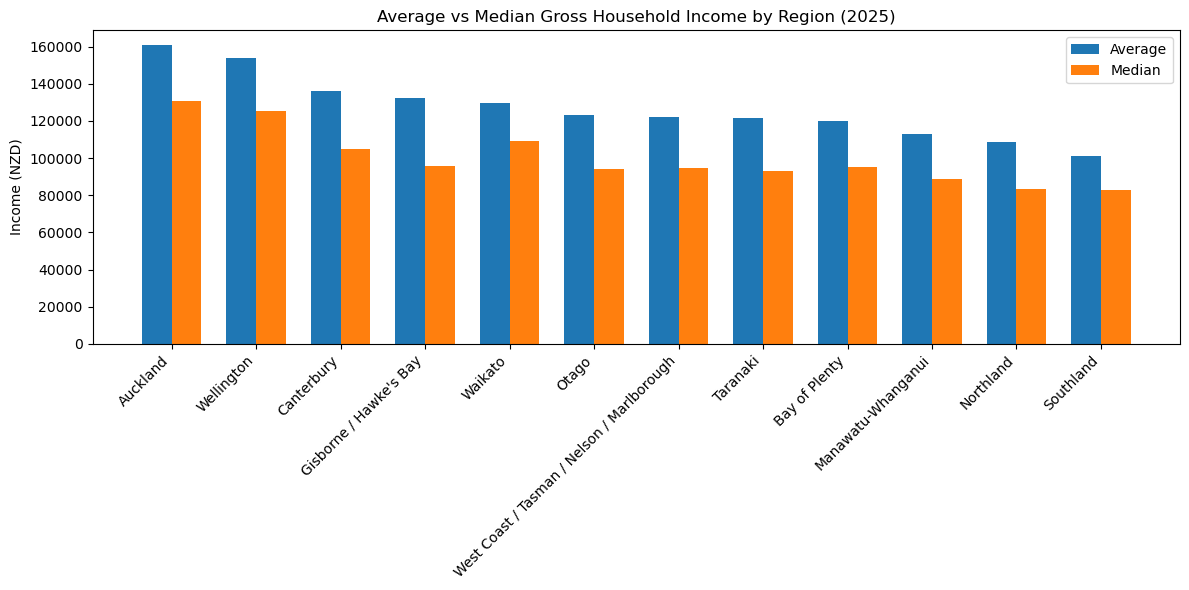

In [18]:
# Compare average and median gross household income

comparison = df[
    (df["Income Type"] == "Gross Income") &
    (df["Measure"].isin(["Average Income", "Median Income"])) &
    (df["Region"] != "New Zealand")
]

pivot = comparison.pivot(
    index="Region",
    columns="Measure",
    values="Estimate"
)

pivot = pivot.sort_values("Average Income", ascending=False)

plt.figure(figsize=(12,6))

x = np.arange(len(pivot))
width = 0.35

plt.bar(x - width/2, pivot["Average Income"], width, label="Average")
plt.bar(x + width/2, pivot["Median Income"], width, label="Median")

plt.xticks(x, pivot.index, rotation=45, ha="right")
plt.ylabel("Income (NZD)")
plt.title("Average vs Median Gross Household Income by Region (2025)")
plt.legend()

plt.tight_layout()
plt.show()

### Key Insights

- In every region, the average household income is higher than the median household income.
- Auckland and Wellington have the highest average and median gross household incomes.
- Southland has the lowest average gross household income among the regions analysed.
- The gap between the average and median income varies by region, suggesting differences in the distribution of household incomes. Regions with a larger gap may have greater income inequality or a higher concentration of high-income households.

## How Do Different Types of Household Income Compare?

Gross household income does not reflect the amount of income households actually have available after taxes and housing costs. This visualisation compares the four income measures reported by Stats NZ to illustrate these differences.

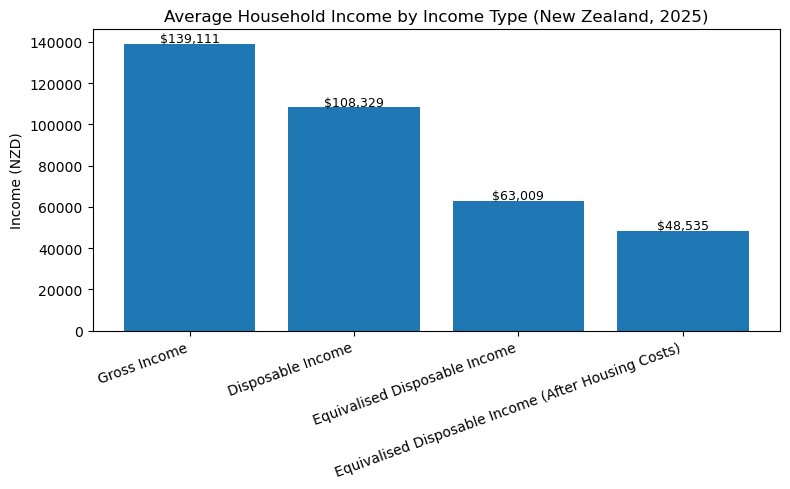

In [20]:
# Compare average income across the four income types

income_compare = df[
    (df["Measure"] == "Average Income") &
    (df["Region"] == "New Zealand")
]

income_compare = income_compare.sort_values("Estimate", ascending=False)

plt.figure(figsize=(8,5))

bars = plt.bar(
    income_compare["Income Type"],
    income_compare["Estimate"]
)

plt.title("Average Household Income by Income Type (New Zealand, 2025)")
plt.ylabel("Income (NZD)")
plt.xticks(rotation=20, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 800,
        f"${height:,.0f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()